In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# EDA

In [2]:
# Load the data
with open('ultimate_data_challenge.json') as f:
    data = json.load(f)
df = pd.DataFrame(data)
df

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,King's Landing,0,2014-01-25,5.0,1.00,2014-06-05,iPhone,0.0,False,100.0,5.63,4.2
49996,Astapor,1,2014-01-24,NaN,1.00,2014-01-25,iPhone,0.0,False,0.0,0.00,4.0
49997,Winterfell,0,2014-01-31,5.0,1.00,2014-05-22,Android,0.0,True,100.0,3.86,5.0
49998,Astapor,2,2014-01-14,3.0,1.00,2014-01-15,iPhone,0.0,False,100.0,4.58,3.5


In [3]:
# Convert date columns to datetime objects
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Determine the reference date for 'current' (last trip recorded in dataset)
last_date = df['last_trip_date'].max()
retention_cutoff = last_date - pd.Timedelta(days=30)

# Define retained users
df['retained'] = df['last_trip_date'] >= retention_cutoff
df

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,True
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0,False
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0,False
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,True
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,King's Landing,0,2014-01-25,5.0,1.00,2014-06-05,iPhone,0.0,False,100.0,5.63,4.2,True
49996,Astapor,1,2014-01-24,NaN,1.00,2014-01-25,iPhone,0.0,False,0.0,0.00,4.0,False
49997,Winterfell,0,2014-01-31,5.0,1.00,2014-05-22,Android,0.0,True,100.0,3.86,5.0,False
49998,Astapor,2,2014-01-14,3.0,1.00,2014-01-15,iPhone,0.0,False,100.0,4.58,3.5,False


In [4]:
# Calculate fraction of retained users
fraction_retained = df['retained'].mean()

print(f"Last trip recorded: {last_date}")
print(f"Retention cutoff date: {retention_cutoff}")
print(f"Fraction of users retained: {fraction_retained:.2%}")

Last trip recorded: 2014-07-01 00:00:00
Retention cutoff date: 2014-06-01 00:00:00
Fraction of users retained: 37.61%


In [5]:
# Check for missing values in each column
missing_values = df.isna().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Display overall info to see data types and non-null counts
df.info()

Missing values per column:
avg_rating_of_driver    8122
phone                    396
avg_rating_by_driver     201
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    50000 non-null  object        
 1   trips_in_first_30_days  50000 non-null  int64         
 2   signup_date             50000 non-null  datetime64[ns]
 3   avg_rating_of_driver    41878 non-null  float64       
 4   avg_surge               50000 non-null  float64       
 5   last_trip_date          50000 non-null  datetime64[ns]
 6   phone                   49604 non-null  object        
 7   surge_pct               50000 non-null  float64       
 8   ultimate_black_user     50000 non-null  bool          
 9   weekday_pct             50000 non-null  float64       
 10  avg_dist                50000 non-null 

In [6]:
# Basic cleaning: Fill missing values for numerical columns
# For ratings, we'll use the mean to avoid losing data
df['avg_rating_by_driver'] = df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].mean())
df['avg_rating_of_driver'] = df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].mean())
df['phone'] = df['phone'].fillna('Unknown')
df

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained
0,King's Landing,4,2014-01-25,4.700000,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,True
1,Astapor,0,2014-01-29,5.000000,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0,False
2,Astapor,3,2014-01-06,4.300000,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0,False
3,King's Landing,9,2014-01-10,4.600000,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,True
4,Winterfell,14,2014-01-27,4.400000,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,King's Landing,0,2014-01-25,5.000000,1.00,2014-06-05,iPhone,0.0,False,100.0,5.63,4.2,True
49996,Astapor,1,2014-01-24,4.601559,1.00,2014-01-25,iPhone,0.0,False,0.0,0.00,4.0,False
49997,Winterfell,0,2014-01-31,5.000000,1.00,2014-05-22,Android,0.0,True,100.0,3.86,5.0,False
49998,Astapor,2,2014-01-14,3.000000,1.00,2014-01-15,iPhone,0.0,False,100.0,4.58,3.5,False


In [7]:
df.describe(include="all")

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained
count,50000,50000.000000,50000,50000.000000,50000.000000,50000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000
unique,3,NaN,NaN,NaN,NaN,NaN,3,NaN,2,NaN,NaN,NaN,2
top,Winterfell,NaN,NaN,NaN,NaN,NaN,iPhone,NaN,False,NaN,NaN,NaN,False
freq,23336,NaN,NaN,NaN,NaN,NaN,34582,NaN,31146,NaN,NaN,NaN,31196
mean,NaN,2.278200,2014-01-16 13:04:20.352000,4.601559,1.074764,2014-04-19 08:02:04.992000256,NaN,8.849536,NaN,60.926084,5.796827,4.778158,NaN
min,NaN,0.000000,2014-01-01 00:00:00,1.000000,1.000000,2014-01-01 00:00:00,NaN,0.000000,NaN,0.000000,0.000000,1.000000,NaN
25%,NaN,0.000000,2014-01-09 00:00:00,4.500000,1.000000,2014-02-14 00:00:00,NaN,0.000000,NaN,33.300000,2.420000,4.700000,NaN
50%,NaN,1.000000,2014-01-17 00:00:00,4.700000,1.000000,2014-05-08 00:00:00,NaN,0.000000,NaN,66.700000,3.880000,5.000000,NaN
75%,NaN,3.000000,2014-01-24 00:00:00,5.000000,1.050000,2014-06-18 00:00:00,NaN,8.600000,NaN,100.000000,6.940000,5.000000,NaN
max,NaN,125.000000,2014-01-31 00:00:00,5.000000,8.000000,2014-07-01 00:00:00,NaN,100.000000,NaN,100.000000,160.960000,5.000000,NaN


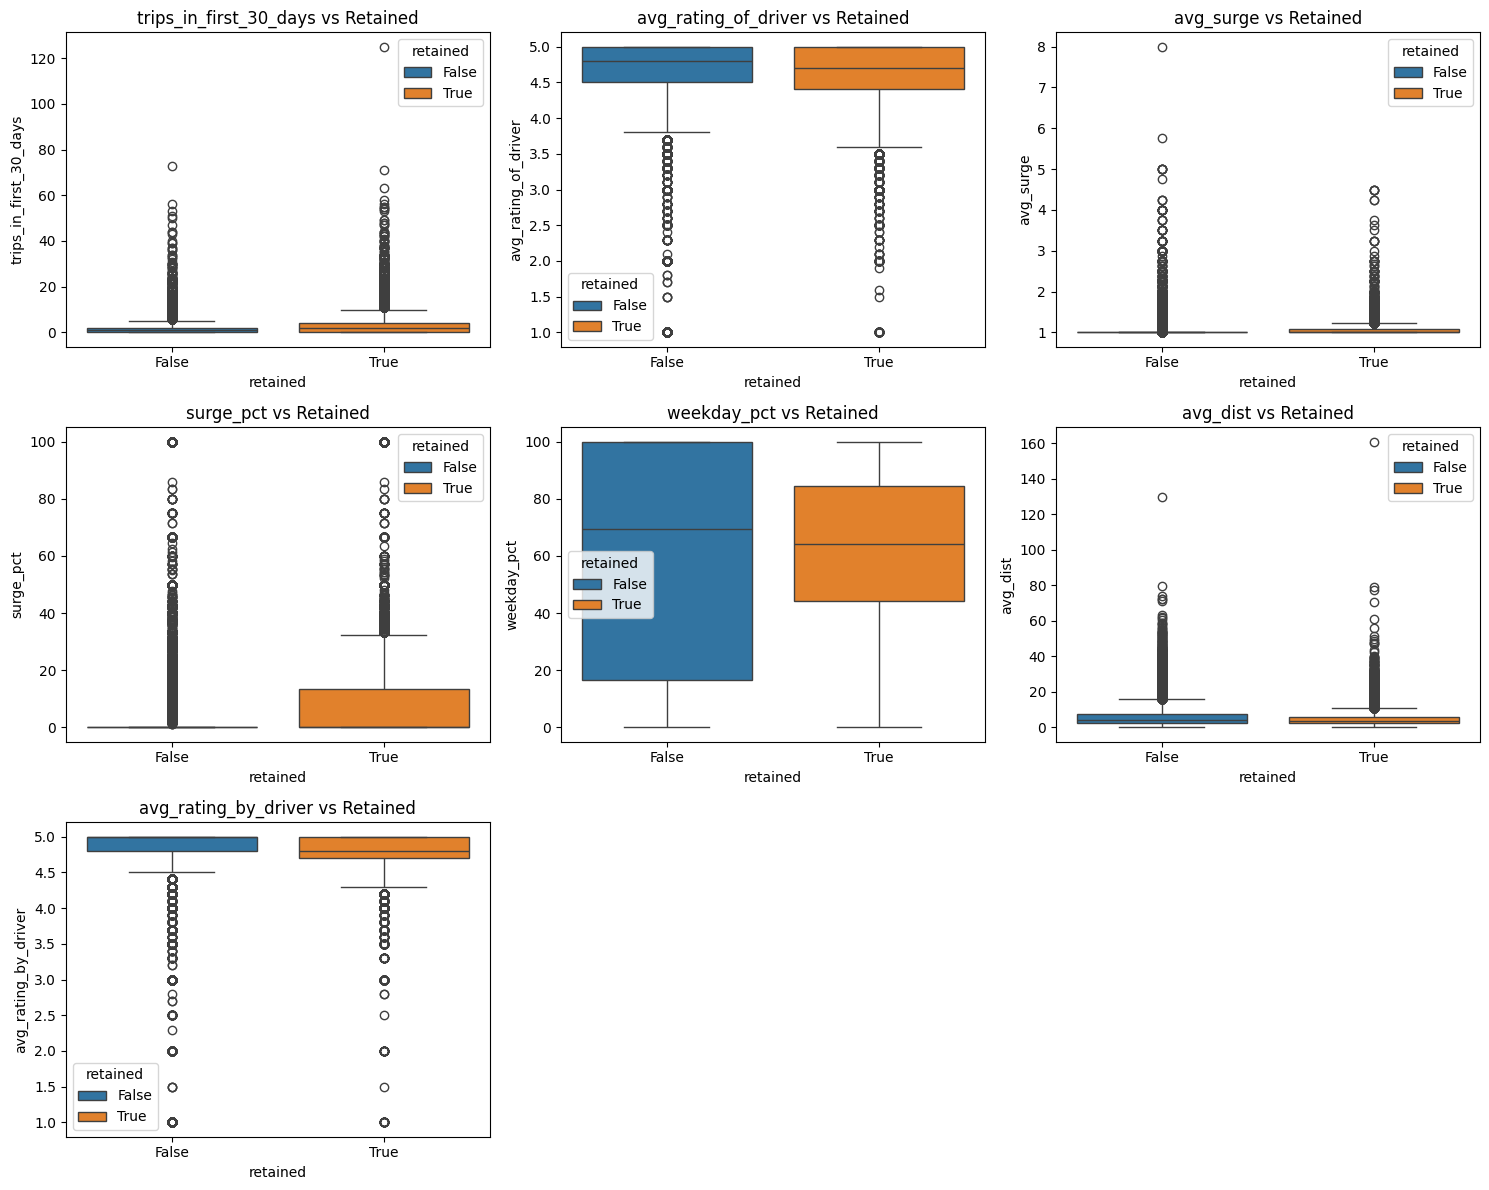

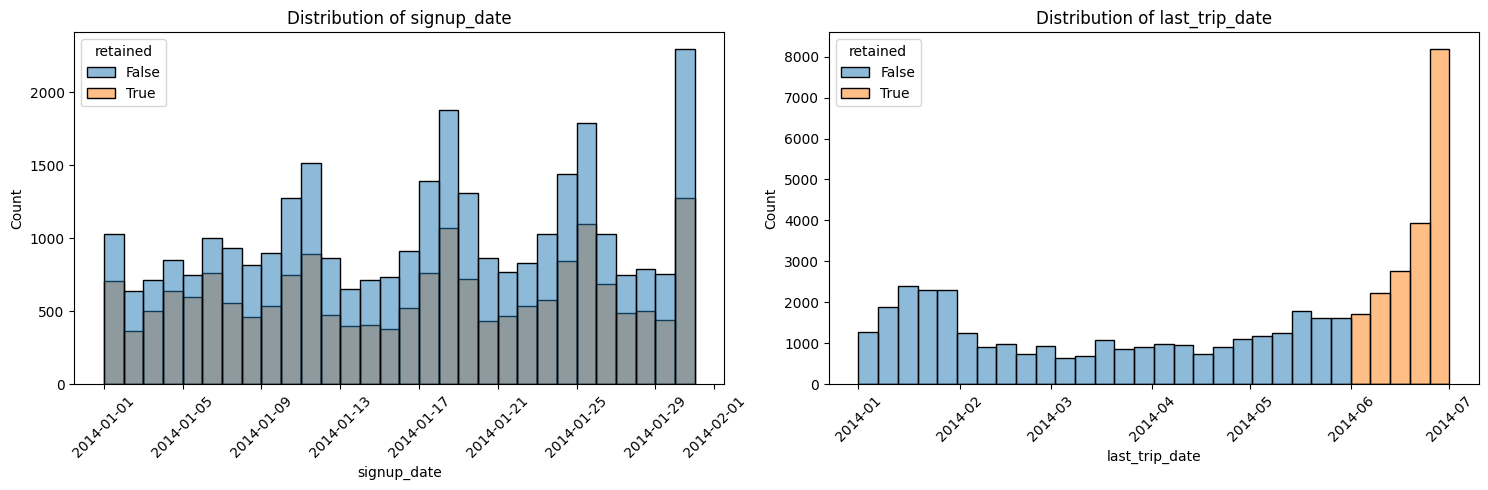

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numeric and datetime columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

# Plot numeric features against retention
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='retained', y=col, hue='retained', data=df)
    plt.title(f'{col} vs Retained')

plt.tight_layout()
plt.show()

# Plot datetime features
plt.figure(figsize=(15, 5))
for i, col in enumerate(datetime_cols, 1):
    plt.subplot(1, 2, i)
    sns.histplot(data=df, x=col, hue='retained', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

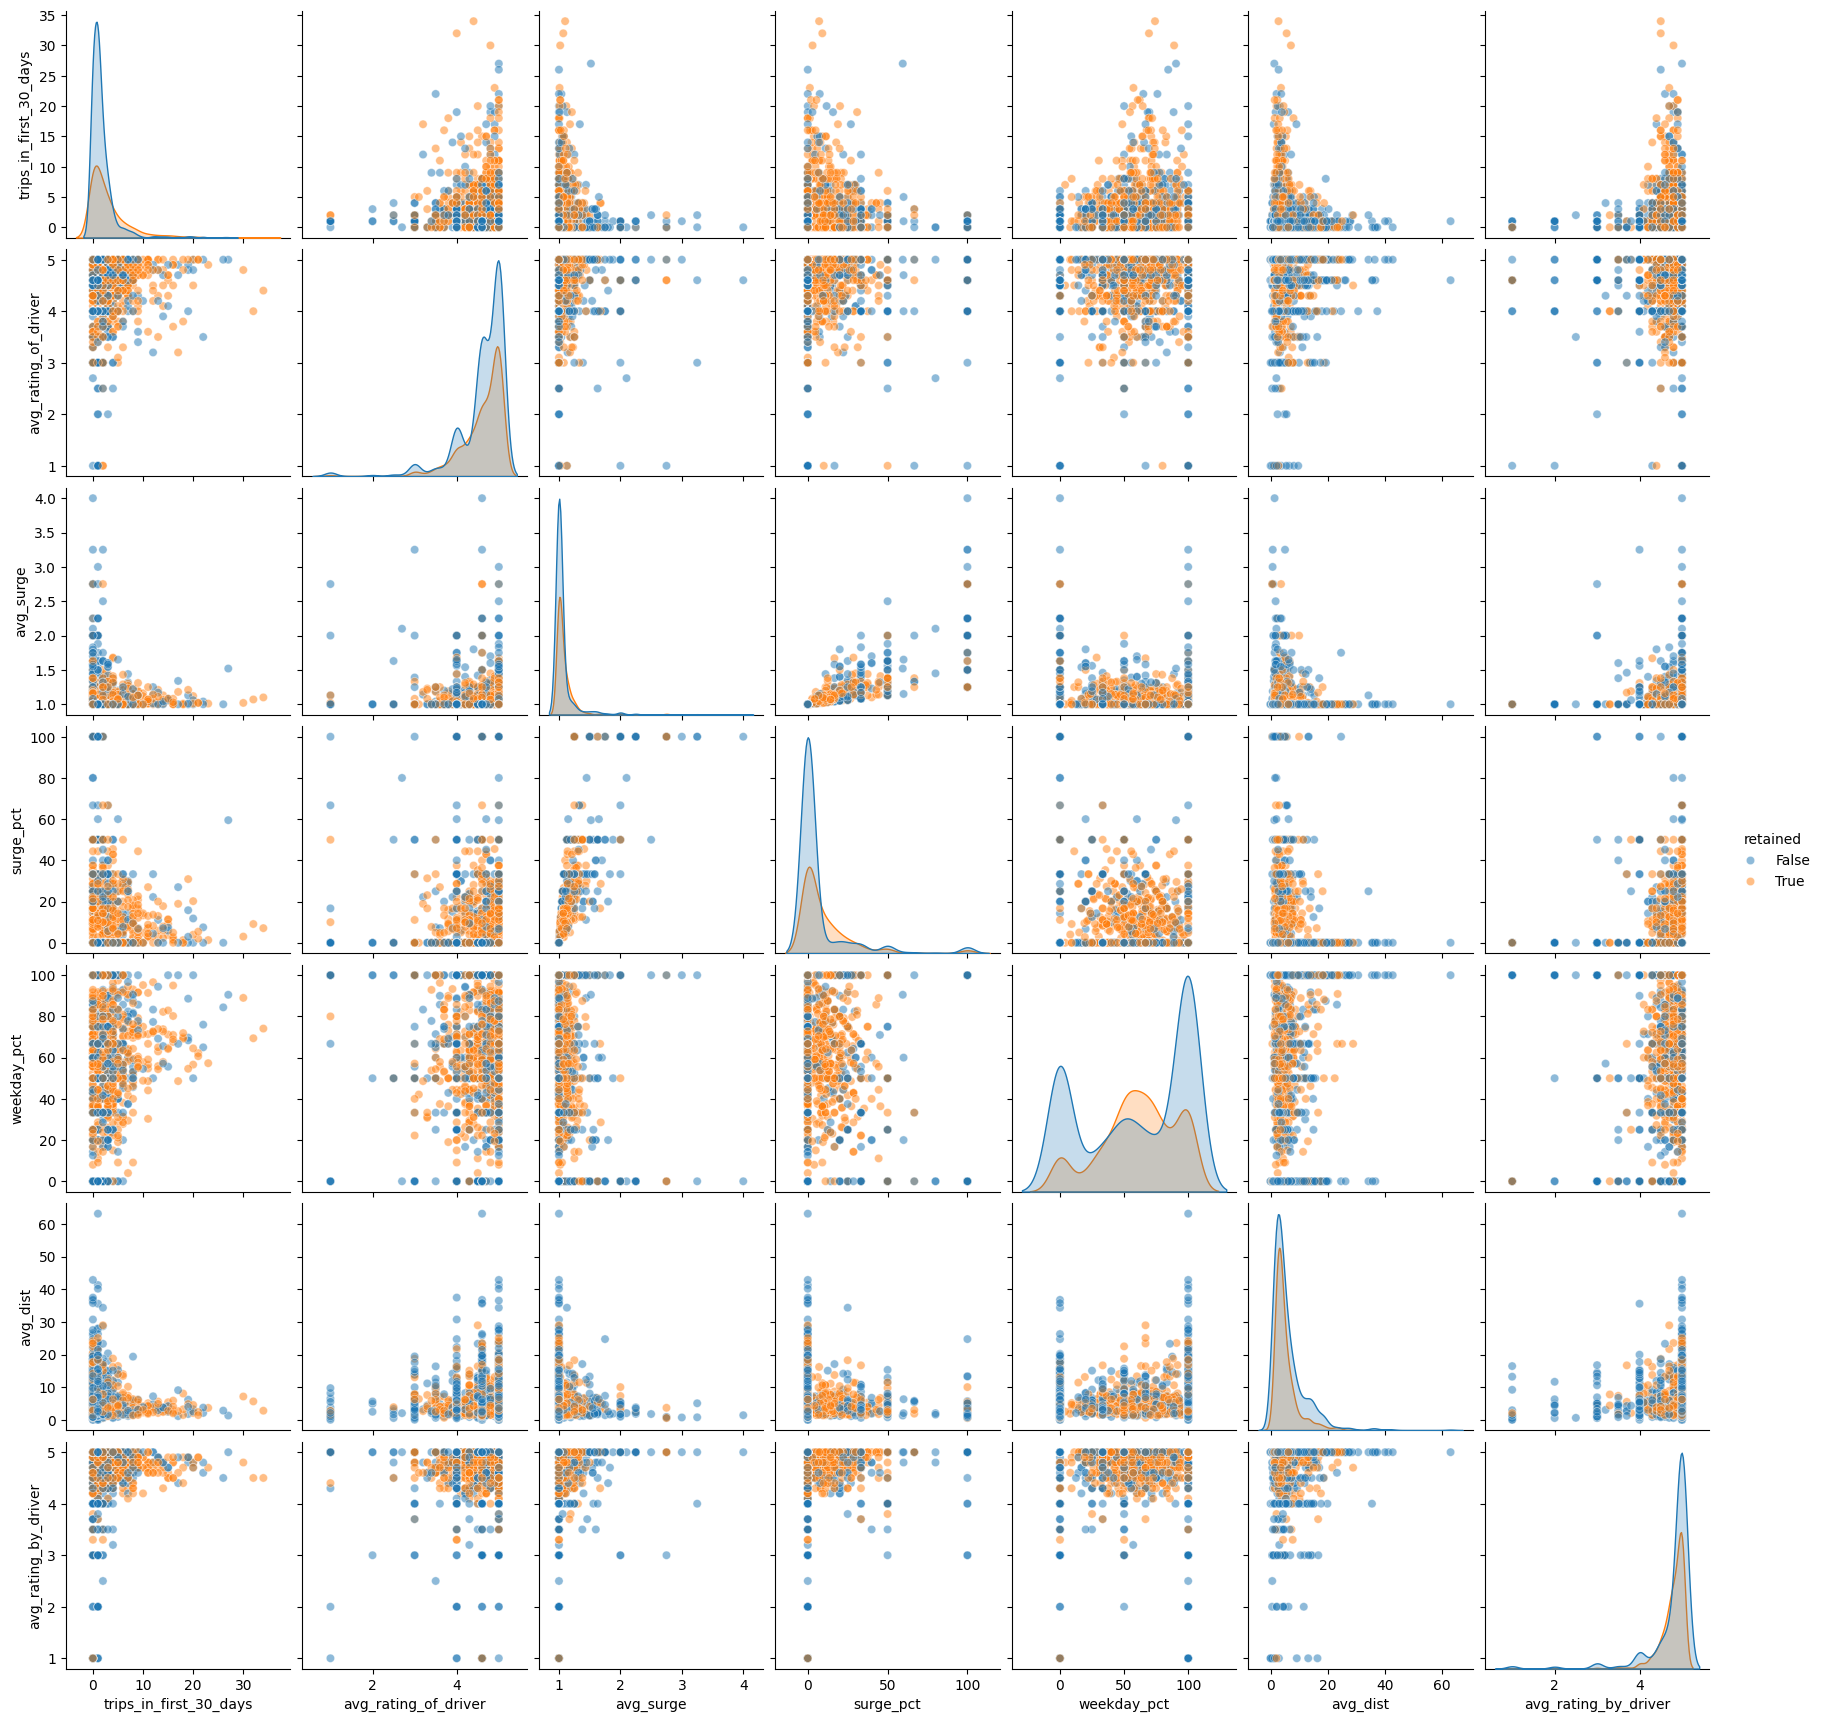

In [9]:
# Using pairplot (which wraps relplot/scatterplot logic) to visualize numeric variables vs each other, colored by retention
# Sampling for performance if the dataset is large
sns.pairplot(df[numeric_cols + ['retained']].sample(min(2000, len(df))), hue='retained', plot_kws={'alpha':0.5})
plt.show()

Difficult to discern a pattern in the relplot.

In [10]:
# Cross-tabulate retention by city
print("Retention by City:")
print(pd.crosstab(df['city'], df['retained']))
print("\n")

# Cross-tabulate retention by phone type
print("Retention by Phone:")
print(pd.crosstab(df['phone'], df['retained']))
print("\n")

# Cross-tabulate retention by Ultimate Black user status
print("Retention by Ultimate Black User Status:")
print(pd.crosstab(df['ultimate_black_user'], df['retained']))

Retention by City:
retained        False  True 
city                        
Astapor         12306   4228
King's Landing   3767   6363
Winterfell      15123   8213


Retention by Phone:
retained  False  True 
phone                 
Android   11876   3146
Unknown     263    133
iPhone    19057  15525


Retention by Ultimate Black User Status:
retained             False  True 
ultimate_black_user              
False                21839   9307
True                  9357   9497


City and phone may be worth dummy encoding.

# CLASSIFICATION

A Random Forest Classifier is best for handling non-linearity, outlier and scaling, and categorical data. It also ranks feature importance.

--- Model Performance Summary ---
Accuracy Score: 75.10%

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      6219
           1       0.68      0.66      0.67      3781

    accuracy                           0.75     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.75      0.75      0.75     10000



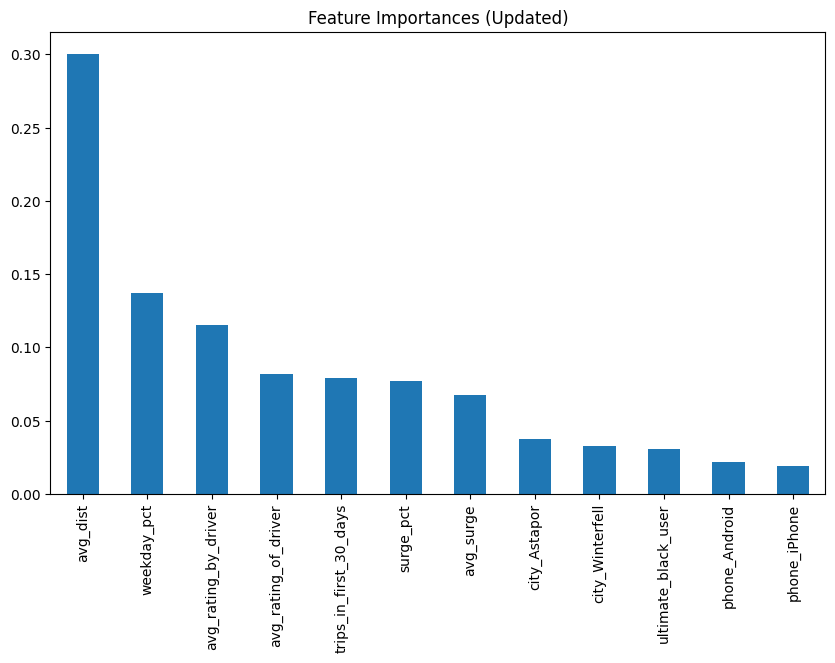

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Data Preparation ---
# Ensure 'Unknown' phone is the one dropped to serve as the baseline for the dummy variables
# We'll use pd.get_dummies and then ensure we are dropping the specific column we want
df_model = pd.get_dummies(df, columns=['city', 'phone'])

# Dropping one category from each to avoid the dummy variable trap
# Specifically dropping 'phone_Unknown' as requested
df_model = df_model.drop(['phone_Unknown', "city_King's Landing"], axis=1, errors='ignore')

# Convert ultimate_black_user and retained to int (0/1)
# This is done for explicit compatibility with Scikit-Learn estimators
df_model['ultimate_black_user'] = df_model['ultimate_black_user'].astype(int)
df_model['retained'] = df_model['retained'].astype(int)

# Define features (X) and target (y)
X = df_model.drop(['retained', 'signup_date', 'last_trip_date'], axis=1)
y = df_model['retained']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- 2. Model Training ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# --- 3. Evaluation ---
y_pred = rf.predict(X_test)

print("--- Model Performance Summary ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importances (Updated)')
plt.show()

# 1. Model Performance & Validity

- Accuracy: ~75.2%, which is a solid improvement over the baseline (predicting 'not retained' for everyone would yield ~62% accuracy).
- Precision/Recall: The model is balanced, though slightly better at identifying non-retained users (Class 0) than retained ones (Class 1). An F1-score of 0.67 for retained users indicates a reliable predictive capability.
- Validity: The model is valid for business use. It effectively identifies high-risk churn users, allowing for targeted intervention.
# 2. Key Predictors (Ranked by Importance)
1. `avg_dist` (Average Distance): The strongest predictor. This suggests that the length of the trip is highly correlated with long-term usage habits.
2. `weekday_pct`: Users who use the service primarily on weekdays vs. weekends show distinct retention patterns.
3. `avg_rating_by_driver`: Interestingly, how drivers rate the riders is a top-three predictor, possibly reflecting rider behavior or 'fit' for the platform.
# 3. Operational Recommendations
- Targeted Marketing in King's Landing: Since retention is highest here, investigate what makes this market successful and attempt to replicate those conditions in Astapor and Winterfell.
- Phone-Specific Optimization: Android users show significantly lower retention (21%) compared to iPhone users (45%). Ultimate should investigate if there are UX/UI bugs or performance issues on the Android app.
- First 30 Days Engagement: The number of trips in the first 30 days is a key feature. Providing incentives (e.g., 'Take 5 trips in your first month for a discount next month') could boost long-term retention.
- Incentivize Mid-Distance Trips: Since avg_dist is the top predictor, users taking very short or very long trips might be outliers. Promoting a 'standard' use case for medium distances might stabilize the user base.